In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("claytonmiller/buildingdatagenomeproject2")

print("Path to dataset files:", path)

100%|██████████| 263M/263M [00:16<00:00, 16.5MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/claytonmiller/buildingdatagenomeproject2/versions/3


In [3]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.covariance import EllipticEnvelope
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [4]:
# BUILDING & ENERGY DISCOVERY
BUILDING_ID = "Panther_lodging_Cora"
DATASET_PATH = path
print(f"Selected Building: {BUILDING_ID}")

CLEANED_ENERGY_FILES = {
    "electricity": "electricity_cleaned.csv",
    "water": "water_cleaned.csv",
    "gas": "gas_cleaned.csv",
    "steam": "steam_cleaned.csv",
    "hotwater": "hotwater_cleaned.csv",
    "chilledwater": "chilledwater_cleaned.csv",
    "irrigation": "irrigation_cleaned.csv",
    "solar": "solar_cleaned.csv"
}

available_energies = []

for energy, filename in CLEANED_ENERGY_FILES.items():
    file_path = os.path.join(DATASET_PATH, filename)
    df_header = pd.read_csv(file_path, nrows=1)
    if BUILDING_ID in df_header.columns:
      available_energies.append(energy)

if len(available_energies) == 0:
    print(f"No cleaned energy data found for building: {BUILDING_ID}")
print("Energies available for analysis:")
for energy in available_energies:
    print(f"- {energy}")

Selected Building: Panther_lodging_Cora
Energies available for analysis:
- electricity
- water
- chilledwater
- irrigation


In [5]:
# METADATA CONTEXT
metadata_path = os.path.join(DATASET_PATH, "metadata.csv")
metadata_df = pd.read_csv(metadata_path)
if "building_id" in metadata_df.columns:
    building_meta = metadata_df[metadata_df["building_id"] == BUILDING_ID]
if building_meta.empty:
    print(f"No metadata found for building: {BUILDING_ID}")
    building_meta = None
else:
    print("Building metadata found.")
    display(building_meta)

Building metadata found.


,building_id,site_id,building_id_kaggle,site_id_kaggle,primaryspaceusage,sub_primaryspaceusage,sqm,sqft,lat,lng,...,yearbuilt,date_opened,numberoffloors,occupants,energystarscore,eui,site_eui,source_eui,leed_level,rating
126,Panther_lodging_Cora,Panther,97.0,0.0,Lodging/residential,Residence Hall,17433.0,187647.0,28.517689,-81.379039,...,2007.0,NaN,NaN,NaN,NaN,151,NaN,NaN,NaN,NaN


In [6]:
# ENERGY-WISE DATA LOADING & TIME-SERIES PREPARATION
energy_timeseries = {}
MIN_NON_NULL_ROWS = 168  # 7 days x 24 hours — minimum for rolling window and lag features

for energy in available_energies:
    print(f"\nPreparing time series for energy: {energy}")
    file_name = f"{energy}_cleaned.csv"
    file_path = os.path.join(DATASET_PATH, file_name)
    df_energy = pd.read_csv(file_path)
    ts_df = df_energy[["timestamp", BUILDING_ID]].copy()
    ts_df.rename(columns={BUILDING_ID: "value"}, inplace=True)
    ts_df["timestamp"] = pd.to_datetime(ts_df["timestamp"])
    ts_df.sort_values("timestamp", inplace=True)
    ts_df.set_index("timestamp", inplace=True)
    ts_df["value"] = pd.to_numeric(ts_df["value"], errors="coerce")

    # Track which positions had real original readings before filling
    original_mask = ts_df["value"].notna()

    # Fill gaps
    ts_df["value"] = ts_df["value"].ffill().bfill()

    # Skip streams with insufficient real data
    if original_mask.sum() < MIN_NON_NULL_ROWS:
        print(f"Skipping {energy}: only {original_mask.sum()} real readings (minimum {MIN_NON_NULL_ROWS})")
        continue

    # Skip degenerate streams where 90%+ values are zero
    zero_ratio = (ts_df["value"] == 0).sum() / len(ts_df)
    if zero_ratio > 0.90:
        print(f"Skipping {energy}: {zero_ratio:.1%} zero values — no meaningful signal")
        continue

    ts_df.attrs["original_mask"] = original_mask
    print(f"Time series prepared: {len(ts_df)} rows, {original_mask.sum()} real readings")
    energy_timeseries[energy] = ts_df
    print(f"Saving file: {energy}_timeseries_{BUILDING_ID}.csv")
    ts_df.to_csv(f"{energy}_timeseries_{BUILDING_ID}.csv", index=True)


Preparing time series for energy: electricity
Time series prepared: 17544 rows, 14193 real readings
Saving file: electricity_timeseries_Panther_lodging_Cora.csv

Preparing time series for energy: water
Time series prepared: 17544 rows, 17478 real readings
Saving file: water_timeseries_Panther_lodging_Cora.csv

Preparing time series for energy: chilledwater
Time series prepared: 17544 rows, 13995 real readings
Saving file: chilledwater_timeseries_Panther_lodging_Cora.csv

Preparing time series for energy: irrigation
Time series prepared: 17544 rows, 7408 real readings
Saving file: irrigation_timeseries_Panther_lodging_Cora.csv


In [7]:
# FEATURE ENGINEERING
feature_data = {}
ROLLING_WINDOW = 24      # 24-hour context
LAG_FEATURES = [1, 24]   # previous hour, previous day
for energy, ts_df in energy_timeseries.items():
    print(f"\nFeature engineering for energy: {energy}")
    df = ts_df.copy()
    df["hour"] = df.index.hour
    df["day_of_week"] = df.index.dayofweek
    df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)
    df["rolling_mean"] = df["value"].rolling(window=ROLLING_WINDOW, min_periods=1).mean()
    df["rolling_std"] = df["value"].rolling(window=ROLLING_WINDOW, min_periods=1).std()
    df["deviation"] = df["value"] - df["rolling_mean"]
    for lag in LAG_FEATURES:
        df[f"lag_{lag}"] = df["value"].shift(lag)

    df_model = df.copy()
    df_model = df_model.ffill().bfill()
    feature_data[energy] = df_model
    print(f"Saving file: {energy}_features_{BUILDING_ID}.csv")
    df_model.to_csv(f"{energy}_features_{BUILDING_ID}.csv",index=True)
    print(f"Feature table shape: {df_model.shape}")
print("\nFeature engineering complete for all energies.")


Feature engineering for energy: electricity
Saving file: electricity_features_Panther_lodging_Cora.csv
Feature table shape: (17544, 9)

Feature engineering for energy: water
Saving file: water_features_Panther_lodging_Cora.csv
Feature table shape: (17544, 9)

Feature engineering for energy: chilledwater
Saving file: chilledwater_features_Panther_lodging_Cora.csv
Feature table shape: (17544, 9)

Feature engineering for energy: irrigation
Saving file: irrigation_features_Panther_lodging_Cora.csv
Feature table shape: (17544, 9)

Feature engineering complete for all energies.


In [8]:
# ENSEMBLE ANOMALY DETECTION
anomaly_results = {}
CONTAMINATION_RATE = 0.03
MAJORITY_VOTE_THRESHOLD = 2

for energy, df in feature_data.items():
    print(f"\nRunning anomaly detection for energy: {energy}")
    features = ["value","rolling_mean","rolling_std","deviation","lag_1","lag_24","hour","day_of_week","is_weekend"]
    X = df[features].values
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    iso = IsolationForest(contamination=CONTAMINATION_RATE, random_state=42, n_jobs=-1)
    iso_pred = iso.fit_predict(X_scaled)
    lof = LocalOutlierFactor(n_neighbors=20, contamination=CONTAMINATION_RATE)
    lof_pred = lof.fit_predict(X_scaled)
    cov = EllipticEnvelope(contamination=CONTAMINATION_RATE, random_state=42)
    cov_pred = cov.fit_predict(X_scaled)

    result_df = df.copy()
    result_df["iso_anomaly"] = (iso_pred == -1).astype(int)
    result_df["lof_anomaly"] = (lof_pred == -1).astype(int)
    result_df["cov_anomaly"] = (cov_pred == -1).astype(int)
    result_df["anomaly_votes"] = result_df["iso_anomaly"] + result_df["lof_anomaly"] + result_df["cov_anomaly"]
    result_df["is_anomaly"] = (result_df["anomaly_votes"] >= MAJORITY_VOTE_THRESHOLD).astype(int)

    # Zero-deviation guard: exclude ffill-filled positions from anomaly flagging
    # Points where value == rolling_mean carry no real signal
    original_mask = energy_timeseries[energy].attrs.get("original_mask")
    if original_mask is not None:
        result_df.loc[~original_mask, "is_anomaly"] = 0
        result_df.loc[~original_mask, "anomaly_votes"] = 0

    anomaly_results[energy] = result_df
    print(f"Anomalies detected: {result_df['is_anomaly'].sum()} / {len(result_df)} ({result_df['is_anomaly'].mean()*100:.2f}%)")


Running anomaly detection for energy: electricity


/usr/local/lib/python3.12/dist-packages/sklearn/covariance/_robust_covariance.py:749: UserWarning: The covariance matrix associated to your dataset is not full rank
  warnings.warn(


Anomalies detected: 218 / 17544 (1.24%)

Running anomaly detection for energy: water


/usr/local/lib/python3.12/dist-packages/sklearn/covariance/_robust_covariance.py:749: UserWarning: The covariance matrix associated to your dataset is not full rank
  warnings.warn(


Anomalies detected: 446 / 17544 (2.54%)

Running anomaly detection for energy: chilledwater


/usr/local/lib/python3.12/dist-packages/sklearn/covariance/_robust_covariance.py:749: UserWarning: The covariance matrix associated to your dataset is not full rank
  warnings.warn(


Anomalies detected: 208 / 17544 (1.19%)

Running anomaly detection for energy: irrigation


/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/covariance/_robust_covariance.py:749: UserWarning: The covariance matrix associated to your dataset is not full rank
  warnings.warn(


Anomalies detected: 141 / 17544 (0.80%)


In [9]:
# ANOMALY EXPLANATION ENGINE
SPIKE_STD_MULTIPLIER = 2
NIGHT_HOURS = list(range(23, 24)) + list(range(0, 6))
WEEKEND_MULTIPLIER = 1.5

def explain_anomaly(row):
    value        = row["value"]
    rolling_mean = row["rolling_mean"]
    rolling_std  = row["rolling_std"]
    hour         = int(row["hour"])
    is_weekend   = int(row["is_weekend"])
    deviation    = row["deviation"]
    lag_1        = row["lag_1"]
    lag_24       = row["lag_24"]

    # Rule 1: Spike above rolling baseline
    if value > rolling_mean + SPIKE_STD_MULTIPLIER * rolling_std:
        return "Sudden spike above 24hr baseline"

    # Rule 2: Night consumption
    if hour in NIGHT_HOURS:
        return "Unusual consumption during night hours (23:00-05:00)"

    # Rule 3: Weekend elevated usage
    if is_weekend == 1 and rolling_mean > 0 and value > rolling_mean * WEEKEND_MULTIPLIER:
        return "Elevated usage on weekend above expected baseline"

    # Rule 4: Sudden change from previous hour
    if rolling_std > 0 and abs(value - lag_1) > SPIKE_STD_MULTIPLIER * rolling_std:
        direction = "increase" if value > lag_1 else "drop"
        return f"Sharp {direction} from previous hour reading"

    # Rule 5: Breaks same-hour pattern from previous day
    if rolling_std > 0 and abs(value - lag_24) > SPIKE_STD_MULTIPLIER * rolling_std:
        direction = "higher" if value > lag_24 else "lower"
        return f"Consumption {direction} than same hour yesterday"

    # Rule 6: Meaningful deviation from baseline
    if abs(deviation) >= 1e-6:
        direction = "above" if deviation > 0 else "below"
        return f"Deviation {direction} building baseline"

    # Rule 7: Flagged on temporal features with zero deviation
    return "Flagged by ensemble based on temporal pattern"

for energy, result_df in anomaly_results.items():
    result_df["explanation"] = ""
    anomaly_mask = result_df["is_anomaly"] == 1
    result_df.loc[anomaly_mask, "explanation"] = result_df[anomaly_mask].apply(explain_anomaly, axis=1)
    anomaly_results[energy] = result_df
    print(f"{energy}: explanations applied to {anomaly_mask.sum()} anomalies")

electricity: explanations applied to 218 anomalies
water: explanations applied to 446 anomalies
chilledwater: explanations applied to 208 anomalies
irrigation: explanations applied to 141 anomalies


In [10]:
# MODEL EVALUATION
evaluation_summary = []
for energy, result_df in anomaly_results.items():
    total_points = len(result_df)
    iso_anoms = result_df["iso_anomaly"].sum()
    lof_anoms = result_df["lof_anomaly"].sum()
    cov_anoms = result_df["cov_anomaly"].sum()
    ensemble_anoms = result_df["is_anomaly"].sum()
    evaluation_summary.append({
        "Energy Type": energy,
        "Total Data Points": total_points,
        "Isolation Forest Anomalies (%)": round(iso_anoms / total_points * 100, 2),
        "LOF Anomalies (%)": round(lof_anoms / total_points * 100, 2),
        "Robust Covariance Anomalies (%)": round(cov_anoms / total_points * 100, 2),
        "Ensemble Anomalies (%)": round(ensemble_anoms / total_points * 100, 2),})
evaluation_df = pd.DataFrame(evaluation_summary)
display(evaluation_df)

,Energy Type,Total Data Points,Isolation Forest Anomalies (%),LOF Anomalies (%),Robust Covariance Anomalies (%),Ensemble Anomalies (%)
0,electricity,17544,3.0,3.0,3.0,1.24
1,water,17544,3.0,3.0,3.0,2.54
2,chilledwater,17544,3.0,3.0,3.0,1.19
3,irrigation,17544,3.0,3.0,3.0,0.80


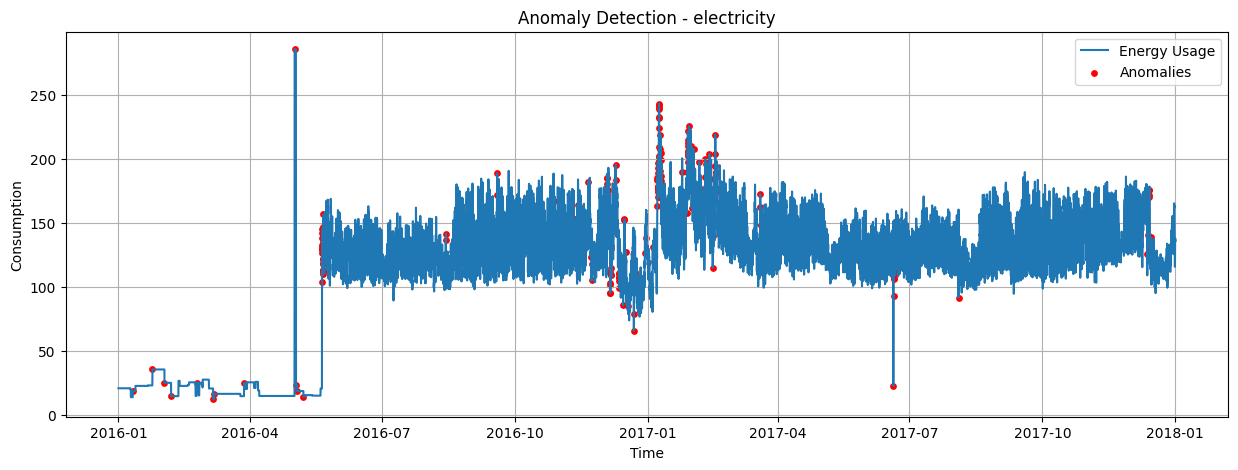

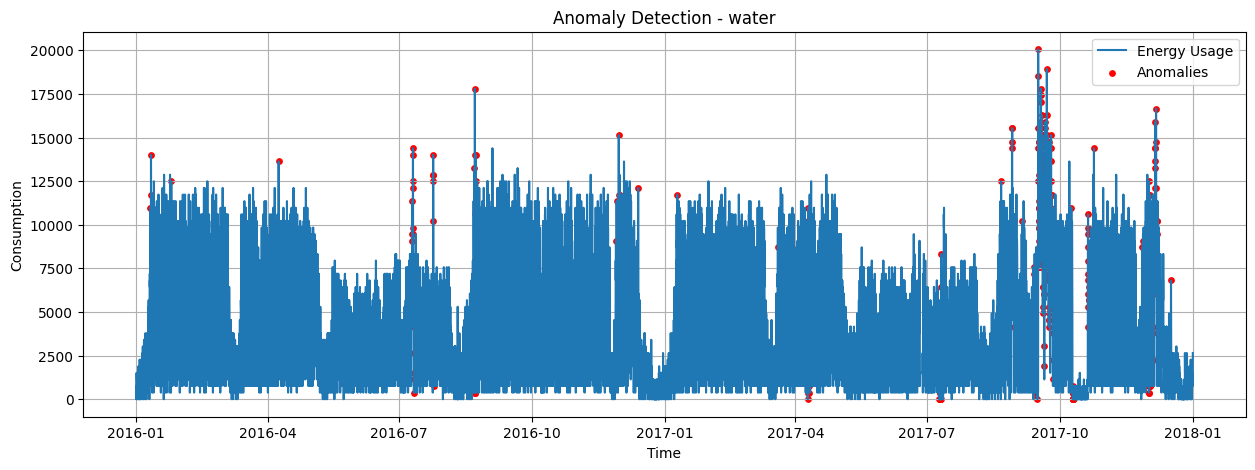

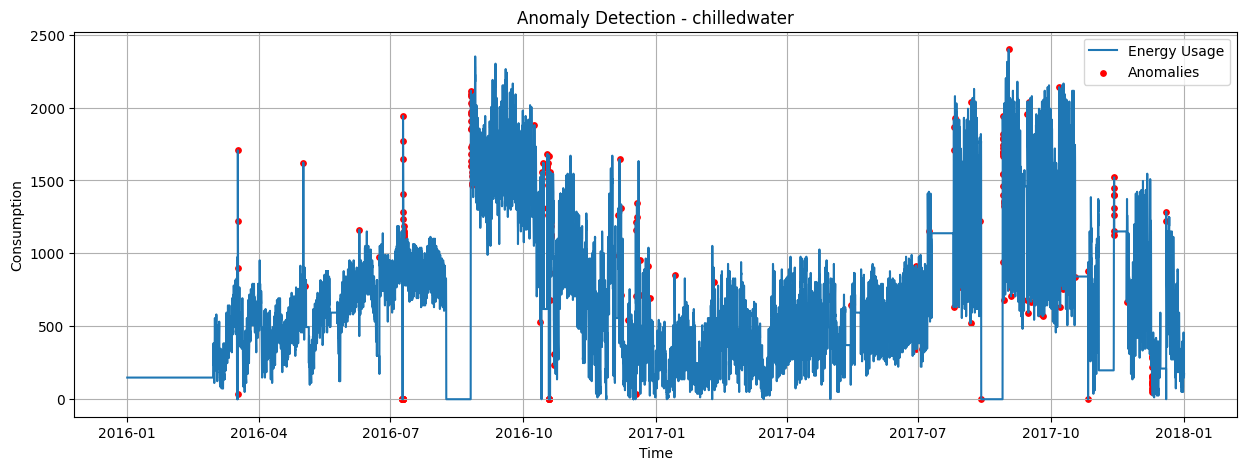

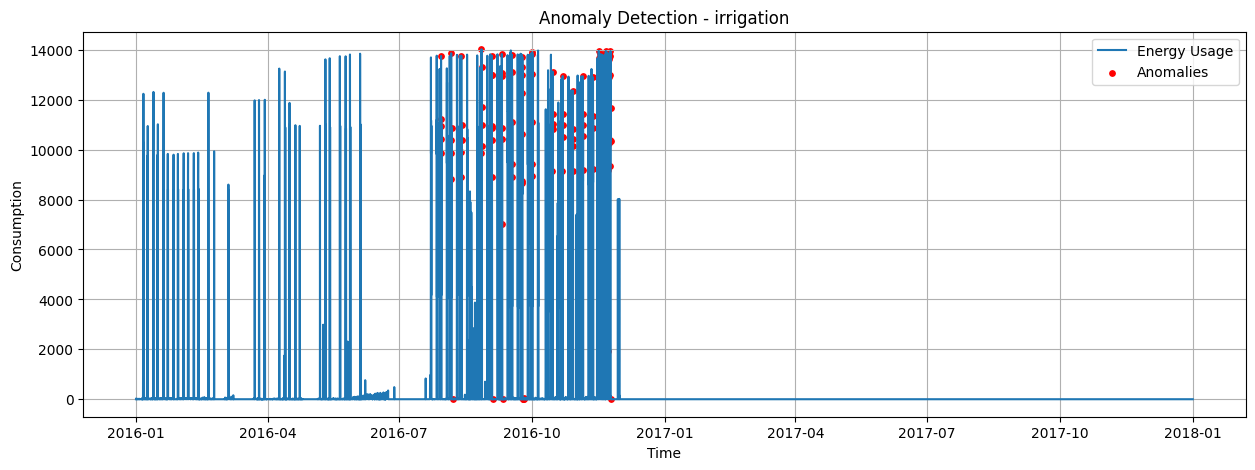

In [11]:
#Visualisation

for energy, df_plot in anomaly_results.items():
    if "value" not in df_plot.columns or "is_anomaly" not in df_plot.columns:
        print(f"Skipping {energy} (missing columns)")
        continue
    plt.figure(figsize=(15,5))
    # Plot normal usage
    plt.plot(df_plot.index, df_plot["value"], label="Energy Usage")
    # Plot anomalies
    anomalies = df_plot[df_plot["is_anomaly"] == 1]
    plt.scatter(anomalies.index, anomalies["value"], color='red', s=15, label="Anomalies")
    plt.title(f"Anomaly Detection - {energy}")
    plt.xlabel("Time")
    plt.ylabel("Consumption")
    plt.legend()
    plt.grid()
    plt.show()

In [12]:
# COST IMPACT ANALYSIS
# Formula: cost = (anomaly_value - normal_baseline_mean) x COST_PER_UNIT
# Only positive excess counts — anomalies below baseline contribute $0
# $0.08/unit is an assumed US commercial energy rate proxy
COST_PER_UNIT = 0.08
cost_summary = []
for energy, df in anomaly_results.items():
    anomalies = df[df["is_anomaly"] == 1]
    if len(anomalies) == 0:
        continue
    normal_mean = df[df["is_anomaly"] == 0]["value"].mean()
    excess_energy = (anomalies["value"] - normal_mean).clip(lower=0)
    excess_cost = (excess_energy * COST_PER_UNIT).sum()
    cost_summary.append({
        "Energy Type": energy,
        "Num Anomalies": len(anomalies),
        "Normal Baseline Mean": round(normal_mean, 4),
        "Excess Energy (above normal)": round(excess_energy.sum(), 4),
        "Estimated Cost Impact (USD)": round(excess_cost, 2),
        "Formula": f"({anomalies['value'].mean():.4f} - {normal_mean:.4f}) x ${COST_PER_UNIT}",
    })

cost_df = pd.DataFrame(cost_summary)
display(cost_df)

,Energy Type,Num Anomalies,Normal Baseline Mean,Excess Energy (above normal),Estimated Cost Impact (USD),Formula
0,electricity,218,112.9766,9.607102e+03,768.57,(150.4318 - 112.9766) x $0.08
1,water,446,4689.5204,1.794997e+06,143599.78,(8004.5295 - 4689.5204) x $0.08
2,chilledwater,208,694.0691,1.074814e+05,8598.52,(1086.9000 - 694.0691) x $0.08
3,irrigation,141,327.0047,1.472662e+06,117812.96,(10753.3135 - 327.0047) x $0.08
